In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
test_loader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

class NC_SSD_Block(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads

        self.qkv_proj = nn.Linear(dim, dim * 3)
        self.out_proj = nn.Linear(dim, dim)

        self.dwconv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

        self.m = nn.Parameter(torch.ones(num_heads, 1, 1))

        self.norm = nn.LayerNorm(dim)

    def forward(self, x, H, W):
        B, L, D = x.shape

        x_spatial = x.transpose(1, 2).view(B, D, H, W)
        x_conv = self.dwconv(x_spatial).flatten(2).transpose(1, 2)

        qkv = self.qkv_proj(x).reshape(B, L, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        c, b, v = qkv[0], qkv[1], qkv[2]

        b = b * self.m

        global_state = torch.matmul(b.transpose(-2, -1), v)

        out = torch.matmul(c, global_state)
        out = out.permute(0, 2, 1, 3).reshape(B, L, D)

        out = self.norm(out + x_conv)
        return self.out_proj(out)

class VSSDBlock(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = NC_SSD_Block(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x, H, W):
        x = x + self.attn(self.norm1(x), H, W)
        x = x + self.mlp(self.norm2(x))
        return x

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class VSSDClassifier(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, num_classes=10, embed_dim=128, depth=4, num_heads=4):
        super().__init__()
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2

        self.patch_embed = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

        self.blocks = nn.ModuleList([VSSDBlock(embed_dim, num_heads) for _ in range(depth)])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        H_g, W_g = x.shape[2], x.shape[3]
        x = x.flatten(2).transpose(1, 2)

        x = x + self.pos_embed

        for block in self.blocks:
            x = block(x, H_g, W_g)

        x = self.norm(x)
        x = x.mean(dim=1)
        return self.head(x)

def train_and_eval(model, train_loader, test_loader, epochs=15, is_cnn=False):
    if is_cnn:
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'epoch_time': []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step()
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = 100. * correct / total

        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        val_loss = test_loss / len(test_loader.dataset)
        val_acc = 100. * test_correct / test_total
        elapsed = time.time() - start_time

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['test_loss'].append(val_loss)
        history['test_acc'].append(val_acc)
        history['epoch_time'].append(elapsed)

        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | "
              f"Test Loss: {val_loss:.4f} | Test Acc: {val_acc:.2f}% | Time: {elapsed:.2f}s")

    return history

epochs_run = 15

print("\nTraining VSSD")
vssd_model = VSSDClassifier().to(device)
vssd_history = train_and_eval(vssd_model, train_loader, test_loader, epochs=epochs_run, is_cnn=False)

print("\nTraining CNN")
cnn_model = SimpleCNN().to(device)
cnn_history = train_and_eval(cnn_model, train_loader, test_loader, epochs=epochs_run, is_cnn=True)

Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 46.0MB/s]



Training VSSD
Epoch 01/15 | Train Loss: 1.8372 | Train Acc: 30.96% | Test Loss: 1.7856 | Test Acc: 34.92% | Time: 31.61s
Epoch 02/15 | Train Loss: 1.5985 | Train Acc: 40.96% | Test Loss: 1.5364 | Test Acc: 44.98% | Time: 24.25s
Epoch 03/15 | Train Loss: 1.4107 | Train Acc: 48.48% | Test Loss: 1.3701 | Test Acc: 50.35% | Time: 24.17s
Epoch 04/15 | Train Loss: 1.2639 | Train Acc: 54.12% | Test Loss: 1.1754 | Test Acc: 57.93% | Time: 24.83s
Epoch 05/15 | Train Loss: 1.1428 | Train Acc: 58.84% | Test Loss: 1.0851 | Test Acc: 61.38% | Time: 24.69s
Epoch 06/15 | Train Loss: 1.0507 | Train Acc: 62.46% | Test Loss: 1.0650 | Test Acc: 61.97% | Time: 23.74s
Epoch 07/15 | Train Loss: 0.9750 | Train Acc: 65.33% | Test Loss: 0.9525 | Test Acc: 66.34% | Time: 22.85s
Epoch 08/15 | Train Loss: 0.9057 | Train Acc: 67.67% | Test Loss: 0.9108 | Test Acc: 67.92% | Time: 24.36s
Epoch 09/15 | Train Loss: 0.8459 | Train Acc: 69.72% | Test Loss: 0.8845 | Test Acc: 69.24% | Time: 24.32s
Epoch 10/15 | Train Lo

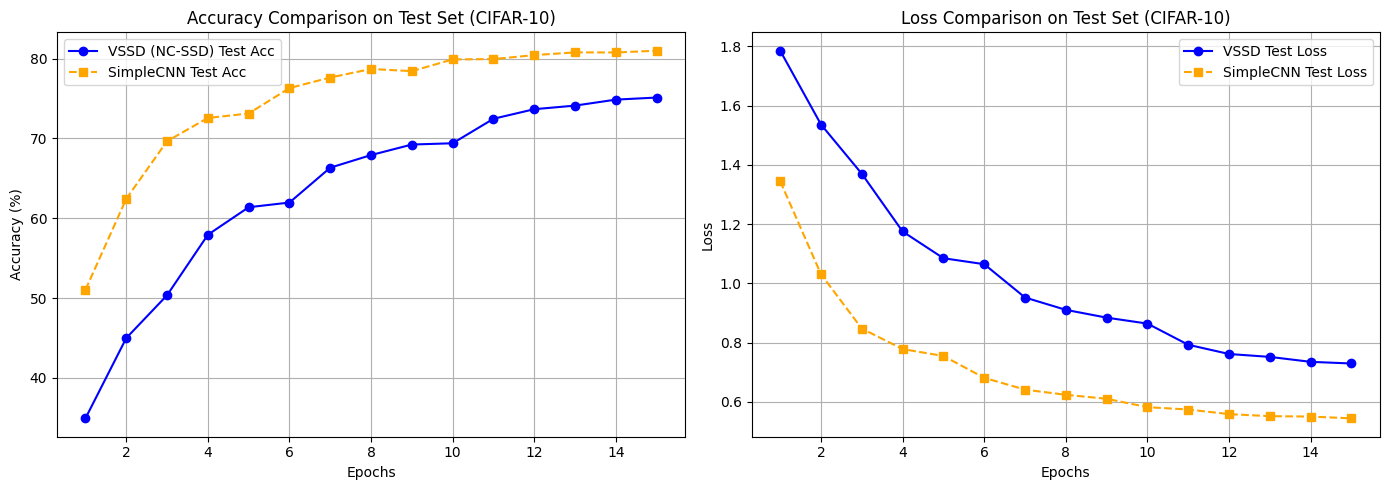

In [ ]:
epochs_range = range(1, epochs_run + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, vssd_history['test_acc'], 'o-', label='VSSD (NC-SSD) Test Acc', color='blue')
plt.plot(epochs_range, cnn_history['test_acc'], 's--', label='SimpleCNN Test Acc', color='orange')
plt.title('Accuracy Comparison on Test Set (CIFAR-10)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, vssd_history['test_loss'], 'o-', label='VSSD Test Loss', color='blue')
plt.plot(epochs_range, cnn_history['test_loss'], 's--', label='SimpleCNN Test Loss', color='orange')
plt.title('Loss Comparison on Test Set (CIFAR-10)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Всё обучалось на T4. Время одной эпохи на более мощных GPU может быть в разы меньше.

На данных CIFAR-10 простая свёрточная нейросеть лидирует: лучше простого трансформера, xLSTM и VSSD. К 6-ой эпохе её результат перебил результат VSSD на 15-ой. При этом обучается быстрее. Однако VSSD тоже показывает достаточно хорошие результаты (учитывая то, что 15 эпох не предел, и моя реализация не совсем идеальная VSSD).

Но VSSD хороша на больших изображениях, где важно видеть сразу много частей (она хорошо улавливает глобальные зависимости). А здесь все изображения 32 x 32, поэтому VSSD не может раскрыть весь свой потенциал.